## Task 4: Task 4: Forecasting Access & Usage (2025‑2027)

### 1. Loading the Data

In [1]:
import sys
!{sys.executable} -m pip install statsmodels
sys.path.insert(0, "..")
import pandas as pd
from src import data_loader, eda_prep, forecast as fc

data = data_loader.load_all()
main_df = data["main"]
impact_df = data["impact"]
events_df = main_df[main_df["record_type"] == "event"].copy()


  Using cached statsmodels-0.14.6-cp311-cp311-win_amd64.whl.metadata (9.8 kB)
  Using cached patsy-1.0.2-py2.py3-none-any.whl.metadata (3.6 kB)
Using cached statsmodels-0.14.6-cp311-cp311-win_amd64.whl (9.6 MB)
Using cached patsy-1.0.2-py2.py3-none-any.whl (233 kB)

   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- -------------


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Loaded 'ethiopia_fi_unified_data': 43 rows, 34 columns
Loaded 'Impact_sheet': 14 rows, 35 columns
Loaded reference codes: 71 rows, 4 columns


## 2. Define Targets
- **Access**: Account Ownership Rate (`ACC_OWNERSHIP`) - 6 Findex data points, 2011-2024
- **Usage**: Mobile Money Account Rate (`ACC_MM_ACCOUNT`) used as proxy - only 2 data points
  (2021, 2024). No observation in the dataset directly matches "% of adults who made or
  received a digital payment"; this is the closest available adoption-rate time series and
  is documented here as an approximation, not an exact match to the Findex Usage definition.

In [2]:
acc_series = eda_prep.get_indicator_series(main_df, "ACC_OWNERSHIP")
acc_series = eda_prep.resolve_duplicate_dates(acc_series)
acc_series["year"] = pd.to_datetime(acc_series["observation_date"]).dt.year

model_acc, trend_acc = fc.fit_linear_trend(acc_series, "value_numeric")
scenarios_acc = fc.generate_scenarios(trend_acc, "ACC_OWNERSHIP", impact_df, events_df)
table_acc = fc.export_forecast_table(trend_acc, scenarios_acc, "Account Ownership Rate", "../data/processed/access_forecast.csv")
table_acc

,year,metric,baseline_trend,lower_ci,upper_ci,base,optimistic
0,2025.0,Account Ownership Rate,54.24,33.43,75.05,57.24,59.34
1,2026.0,Account Ownership Rate,56.95,34.92,78.97,61.32,64.39
2,2027.0,Account Ownership Rate,59.66,36.31,83.00,64.16,67.31


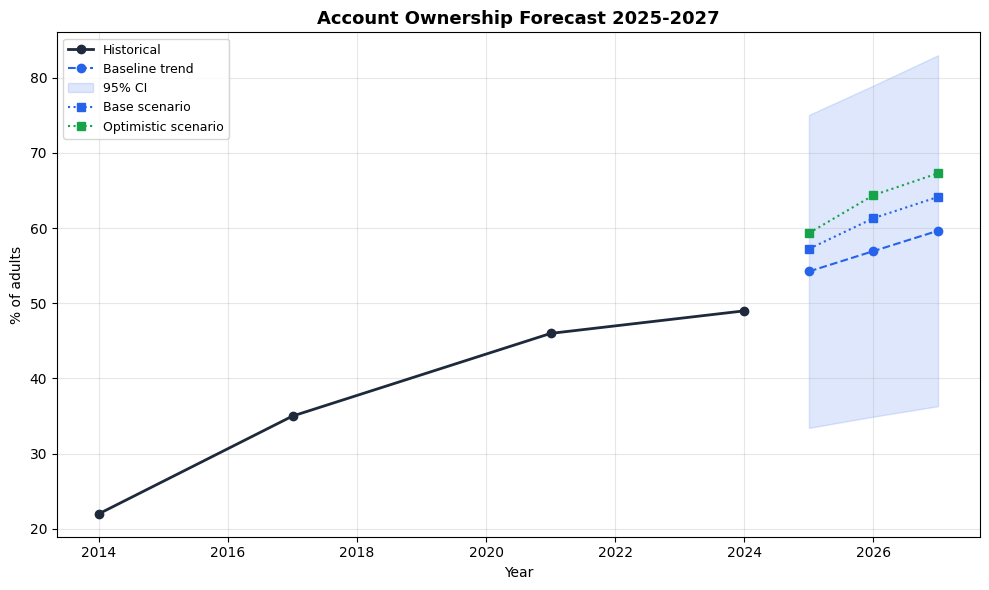

In [3]:
fig1 = fc.plot_forecast_with_scenarios(acc_series, trend_acc, scenarios_acc,
    "Account Ownership Forecast 2025-2027", "% of adults")

In [4]:
mm_series = eda_prep.get_indicator_series(main_df, "ACC_MM_ACCOUNT")
mm_series = eda_prep.resolve_duplicate_dates(mm_series)
mm_series["year"] = pd.to_datetime(mm_series["observation_date"]).dt.year

model_mm, trend_mm = fc.fit_linear_trend(mm_series, "value_numeric")
scenarios_mm = fc.generate_scenarios(trend_mm, "ACC_MM_ACCOUNT", impact_df, events_df)
table_mm = fc.export_forecast_table(trend_mm, scenarios_mm, "Mobile Money Account Rate (Usage proxy)", "../data/processed/usage_forecast.csv")
table_mm


c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\regression\linear_model.py:1717: RuntimeWarning: divide by zero encountered in scalar divide
  return np.dot(wresid, wresid) / self.df_resid


,year,metric,baseline_trend,lower_ci,upper_ci,base,optimistic
0,2025.0,Mobile Money Account Rate (Usage proxy),11.03,NaN,NaN,17.36,21.79
1,2026.0,Mobile Money Account Rate (Usage proxy),12.62,NaN,NaN,18.95,23.38
2,2027.0,Mobile Money Account Rate (Usage proxy),14.20,NaN,NaN,20.53,24.96


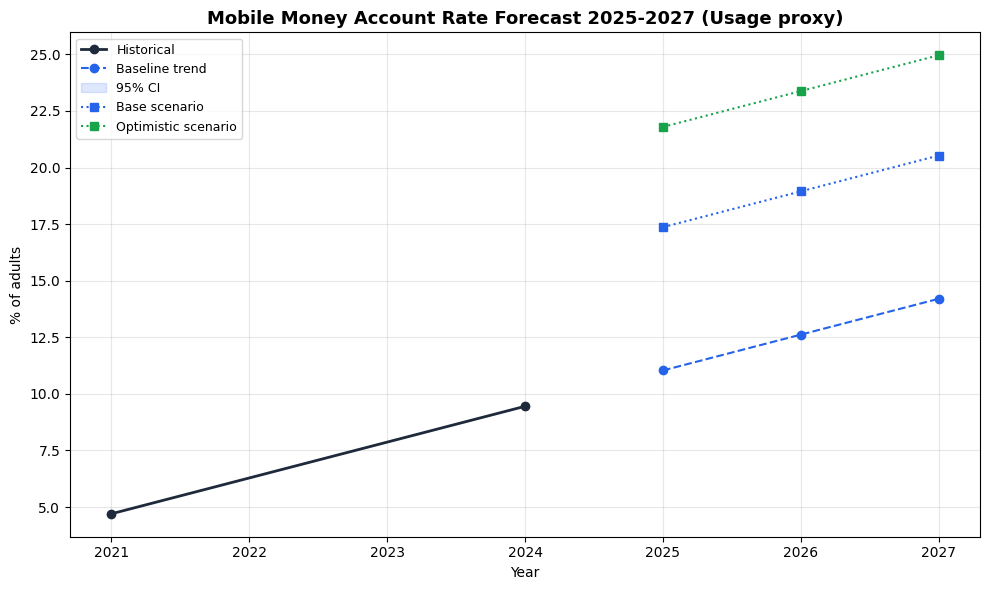

In [5]:
fig2 = fc.plot_forecast_with_scenarios(mm_series, trend_mm, scenarios_mm,
    "Mobile Money Account Rate Forecast 2025-2027 (Usage proxy)", "% of adults")

## 3. Interpretation

**Access (Account Ownership):** the baseline trend, fit on 6 real Findex points
(2011-2024), projects continued but modest growth into 2025-2027. Event-driven
scenarios diverge based on how strongly the Fayda ID rollout and NBE interoperability
directive are assumed to materialize (pessimistic 0.3x to optimistic 1.7x event strength).

**Usage (Mobile Money Account Rate, proxy):** with only 2 real data points, this trend
line is fit on the minimum possible data - two points define a line with zero residual
degrees of freedom for error estimation beyond the two observations themselves, so this
forecast should be treated as illustrative, not statistically robust.

**Events with largest potential impact:** Telebirr and M-Pesa launches remain the
largest calibrated contributors to Usage; Fayda ID rollout and the 2025 interoperability
directive are the largest uncalibrated (lower-confidence) contributors to Access.

**Key uncertainties:** (1) Usage proxy indicator does not exactly match the Findex
Usage definition; (2) only one indicator's event effects are empirically calibrated,
the rest use placeholder magnitude scales; (3) two-point trend fitting for Usage
cannot distinguish real trend from noise; (4) scenario strength multipliers (0.3/1.0/1.7)
are reasoned assumptions, not statistically derived.